# Introduction
The primary objective of this lab is to familiarise you with the basic mechanics that allow you to get hold of satellite data for the purposes of carrying out machine learning. The second objective is for you to put into practice some of the theory that we covered in lectures 1 and 2, in order that you can start to understand some of the specific quirks and potentially powerful attributes of satellite data when it comes to applying machine learning techniques.

This lab has drawn upon the following sources, tutorials and repos:


*   https://geemap.org/
*   https://developers.google.com/earth-engine

Whenever you see a numbered question, e.g. '(1)', make sure that you answer it in the answer proforma and submit the resulting document on Canvas. Only submit in .docx or .pdf formats (we cannot open 'pages' etc docs on Canvas).

If you want to submit code as your 'working' OR we ask you to give your code as part of the answer, give a link in your proforma document to a Colab notebook that is stored in a place we can access (your own GitHub account for example!).

Some of the questions will be relatively simple and are designed to get you thinking about the nature of the code and what it is doing, whilst also requiring you to pull in theoretical knowledge from the lectures. Other questions are exercises that ask you to both apply this knowledege to a new challenge and/or require you to independently go and seek answers.

In all cases I encourage you to give it a go, even if you do not have the full answer. Particularly for the larger challenges ('Exercises'), marks are awarded for workings and I want to see your thought process in action via the code you write.

Use text comments as demonstrated in these lab instructions to explain your thinking and communicate with the person marking your work.

I use both comments above chunks of code to tell you the overall objectives of that code, and inline comments to highlight specific features and elements to be aware of (formatted like this to draw your attention '#<-').

You are expected to present outputs to a professional standard. This means maps must have scales, north arrows and legends that are readable. For a good guide to all matters professional figure drawing, see this Nature guide:
*    https://research-figure-guide.nature.com/figures/preparing-figures-our-specifications/.

A portion of the marks are for presentation and communication.

# Set up

In [1]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-project')

In [2]:
# Install the geemap package (only needs to be run once, uncomment below and run it the first time you run this notebook in a session).
#!pip install geemap

In [3]:
import geemap

# Loading a map and displaying satellite data

In [4]:
# Use the built in functions to load an ipyleaflet basemap (this is a UI to explore and see what we are doing)
# Note that I used to show you Open Street Map here, but there is currently a tile/scraper battle going on, and notebooks have been caught in the cross-fire.
Map = geemap.Map(center=(-41, 172), zoom=4, basemap="HYBRID")
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [5]:
# Specify a different kind of basemap to display data layers over
Map = geemap.Map(center=(-41, 172), zoom=4) #<- note the lat-lon coordinate pair here
Map.add_basemap("USGS.USImageryTopo")
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland.
Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

In [6]:
from ipyleaflet import ScaleControl, WidgetControl
import ipywidgets as widgets
import folium

# 1. Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland.
# Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

map = geemap.Map(center=(-36.9, 174.75), zoom=10)
map.add_basemap("OpenTopoMap")
scale = ScaleControl(position="bottomleft", imperial=False)
map.add(scale)

map

Map(center=[-36.9, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [7]:
# Add Earth Engine datasets to our map by first creating variables to hold the calls to the EE api
Map = geemap.Map(center=(-41, 172), zoom=4)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
states = ee.FeatureCollection("TIGER/2018/States")

In [8]:
# Set visualization parameters.
vis_params = {
    "min": 0,
    "max": 4000, #<- if your satellite image is all white or all black, these vis params are the first thing to check and change
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"], #<- these are HTML colour codes
}

In [9]:
# Add a variety of different Earth Engine layers to the Map object
Map.addLayer(dem, vis_params, "SRTM DEM", True, 0.5) #<- note vis params called from the dictionary we set up before
Map.addLayer(landcover, {}, "Land cover")
Map.addLayer(
    landsat7, {"bands": ["B4", "B3", "B2"], "min": 20, "max": 200}, "Landsat 7" #<- note vis params in a dictionary here inside the add layer call
)
Map.addLayer(states, {}, "US States")

In [10]:
 # Dump all of this into the map view and take a look...
# Scroll around (look at both NZ and USA), check and uncheck the layers in the layer menu on the top-right.
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

(2) The Landsat 7 data displays as red colored/tinged image. Why is this? [Think about both the content in Lecture 1, and what is going on when you visualize a satellite image]. (2 pts)

Landsat 7 displays a red coloured/tinged image due to the incoming electromagnitic radiation coming into the satilites sensor. Chlorophyll in healthy plants absorbs red light for photosynthisis and reflects near-infrared wavelenths meaning these wavelengths are translated to red bands in areas with vegetation. which is why so much of the area is twinges red.

(3) Correct the display of the Landsat 7 image so that it displays in '[True Colour](https://weather.ndc.nasa.gov/sport/training/quickGuides/rgb/QuickGuide_TrueColorRGB_NASA_SPoRT.pdf)'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

In [11]:

Map = geemap.Map(center=(33, 18), zoom=3)
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
Map.addLayer(
    landsat7, {"bands": ["B3", "B2", "B1"], "min": 0.0, "max": 80}, "Landsat 7" # change the bands to repersent the true colours and adjust the max so the colours are distbuted along the reflectance evenly for visuliseation.
)

Map

Map(center=[33, 18], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

# Spectral reflectance curves
Next we we will generate a spectral reflectance curve for a given area.
This is a useful tool when you are considering if a given target has spectral characteristics for identification in ML. If everything has the same spectral signature, then you need to take a different approach to a simple spectral classification, as might have been the first instinct of a classical remote sensing scientist before the advent of machine learning.

In [12]:
# Add in a library for plotting the data we extract
import matplotlib.pyplot as plt

In [13]:
# Define a point and a small rectangular region around it
point = ee.Geometry.Point([174.7633, -36.8485])  # Auckland, NZ
region = point.buffer(150).bounds()  # ~300 m box

In [14]:
# Load a Landsat 7 Collection 2 Level 2 SR image (surface reflectance)
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()

(4) Why are we using the surface reflectance (SR) here rather than the top of atmosphere (ToA)? (2 pt)

surface reflectance is the proportion of light reflected at the earths surface for diffrent wave lengths, where as top of atmoshere includes all of the spectral reflectance absorbed by the satlite includeing that light reflected from clouds and the atmosphere. Surface reflectance is therefore used because it can be used to idnentfy diffrent objects on earths surface by thir wavelengths without interference from atmospheric conditions.  

In [15]:
# Select surface reflectance bands and apply scale factor
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}

scale_factor = 2.75e-5  # From USGS documentation for Landsat C2 L2

(5) What is a 'scale factor' as has been used in the prior code cell, and why are they used in satellite data storage-to-processing workflows such as this? (2 pts)


Satlite imagagry is initaly sotred in didgital numbers. a scaling factor needs to be applied to these digital numbers to convert them to reflectance values for the surface reflectance curve.






**Important sidenote**

The 'reduce' operation is a key concept in the backend of how Google is storing and serving us large quanities of satellite data. GEE uses 'reducers' in multiple ways, many of which are not always immediately intuitive. Check out the docs for more information:

*   https://developers.google.com/earth-engine/guides/reducers_intro

Here we are using a reduce operation over the specified small sample area in order to find the mean of all the cells that lie within the region:

In [16]:
# Reduce region to mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6
)

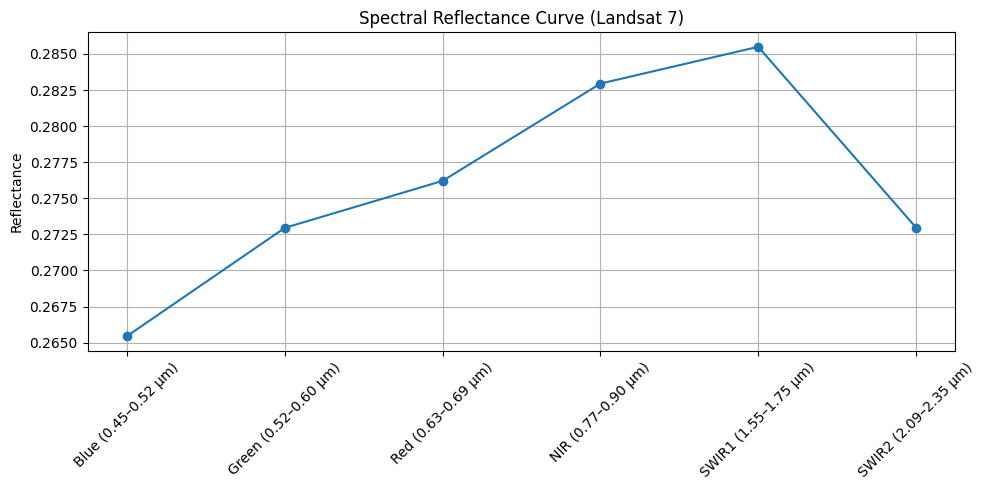

In [17]:
# Extract and scale values
mean_values = mean_dict.getInfo()
reflectance = [mean_values[b] * scale_factor for b in bands]

# Plot the spectral curve
plt.figure(figsize=(10, 5))
plt.plot(list(band_names.values()), reflectance, marker='o', linestyle='-')
plt.title('Spectral Reflectance Curve (Landsat 7)')
plt.ylabel('Reflectance')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

(6) If we want to apply multiple reducers to the same inputs what is a more efficient way to do so than just writing out a long series of sequential reducers on our end? (2 pts)

Use the combine() function after calling the inital reducer to add another reducer to the same input. sharedInputs: true means that only a single pass is made over the data which helps effcenicy.

# Cloud cover
A final consideration that I want to cover in this lab is that of cloud cover. Cloud cover removal is a complex and often difficut process that GISCI 341 students spend an entire two weeks tackling as a focus (so use them in your teams!). However, for our purpose here lets just use the basic in-built cloud clearing native to the Landsat 7 collection on GEE.

In [18]:
# Define small region around Auckland, NZ
point = ee.Geometry.Point([174.7633, -36.8485])
region = point.buffer(500).bounds()

# Load the image with least cloud cover in 2002
image = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(region) \
    .filterDate("2002-01-01", "2002-12-31") \
    .sort("CLOUD_COVER") \
    .first() #<- note the filtering step that is being applied here! We are taking the first image in a sorted by cloud cover response.

# Check metadata
print('Image ID:', image.get('LANDSAT_PRODUCT_ID').getInfo())
print('Cloud Cover (whole scene):', image.get('CLOUD_COVER').getInfo())

Image ID: LE07_L2SP_073086_20020827_20200916_02_T1
Cloud Cover (whole scene): 1


In [19]:
# Function to mask clouds using QA_PIXEL band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 and 4 are cloud and cloud shadow respectively
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(
                 qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(cloud_mask)

# Apply mask
masked_image = mask_clouds(image)

**Important side note**

In the function above we are using a bitwise operation in order to search through the quality assurance (QA) band of the image. Different satellites have different bit-masks. Read more about bitmasks and how they are used here:
*   https://spatialthoughts.com/2021/08/19/qa-bands-bitmasks-gee/



**Another important side note**

You will have noticed that we are frequently running code and not seeing anything happen in terms of output in the cell or changes in the RAM/Disk of the Colab instance (check the small graphs top right). This is deliberate! Satellite data is large and hard to wrangle. GEE does a lot of the work for us, hence we can explore and get into it so quickly. Part of how it does this is by not executing any of your API calls until you specifically ask for an output to be sent back to you. Prior to calling an output (usually through a 'AddLayer' or similar call), when using the GEE/EE API you are essentially chaining together a lot of dot-operators (e.g. '.sort \ .reduce') into a series of instructions that are verified, but only then acted on when required.

This is the result of a 'client vs. server' approach. For more detail, that will help you understand why you can and cannot do certain things, see:
*   https://developers.google.com/earth-engine/guides/client_server



In [20]:
# Report Image Quality Over ROI
# Total pixels in region
pixel_area = ee.Image.pixelArea().clip(region)

# Count valid pixels before and after masking
total_pixels = pixel_area.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['area']

valid_pixels = masked_image.select('SR_B3').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['SR_B3']

cloud_coverage_pct = 100 * (1 - valid_pixels / total_pixels)

print(f"Total Pixels: {total_pixels}")
print(f"Valid (non-cloud) Pixels: {valid_pixels}")
print(f"Estimated Cloud Coverage in ROI: {cloud_coverage_pct:.2f}%")

Total Pixels: 1394
Valid (non-cloud) Pixels: 1050
Estimated Cloud Coverage in ROI: 24.68%


In [21]:
# Visualize the before and after
Map = geemap.Map(center=[-36.8485, 174.7633], zoom=12)

vis = {
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}

Map.addLayer(image, vis, 'Original Image (Cloudy)')
Map.addLayer(masked_image, vis, 'Cloud Masked')
Map

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

(7) Produce a table that tells me the average amount of cloud cover per LandSat image in a year: for 2005, 2010 and 2015. Do this over a region of your choice, as a percentage.

Provide a notebook example of your code that does so, in addition to your table. (5 pts)

In [22]:

# Define small region (ROI) around Queenstown, NZ
point = ee.Geometry.Point([168.7633, -45.8485])
region = point.buffer(500).bounds()

# get all landsat 7 images from 2005
collection = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(region) \
    .filterDate("2005-01-01", "2005-12-31") # makes a data collection of every landsat7 image captured over the ROI in 2005


# calcuate the cloud percentage inside ROI for a single image
def compute_roi_cloud_pct(img): # def is used to define the function (block of code)
  qa = img.select('QA_PIXEL') # qa is defined here so any other code that needs it has to be indeted so its inline to this

#idenfy wether cload or shadow
  is_cloud_or_shadow = qa.bitwiseAnd(1 << 3).neq(0).Or(
    qa.bitwiseAnd(1 << 4).neq(0)) # Bits 3 and 4 are cloud and cloud shadow respectively

#ee.reducer.mean(gives the proportion of cloudy pixels inside the area of interest)
  # usees the cloud or shadow which have the area 1 for cloud and 0 for clear sky
  # to classify queenstown at 30meter resolution and then the reducer.mean caluated the proprtion of the area coved by cloads
  #.get extracts only the decimal proprtion of cloud cover.
  cloud_fraction = is_cloud_or_shadow.reduceRegion(
    reducer=ee.Reducer.mean(), # mean reducer calculates tha average over the area
    geometry=region, # use queenstown region
    scale=30, # sets tha spacial resolution to 30m same as the landsat 7 sensor
    maxPixels=1e9 # sets a limit on the amount of pixels
).get('QA_PIXEL') # extracts the raw numeric result to it can be stored inside cloud_fraction

# Convert fraction to percentage and attach as metadata property
  return img.set('roi_cloud_pct', ee.Number(cloud_fraction).multiply(100))
  #ee.number converts the computed fraction so that it can be used in math operations
  #.multiply converts from fraction to percentage (ov)
  # img.set(roi_cloud_pct,..) creates a new metadata propety to store the percentafes named 'roi_cloud_pct
  # return passes the newly labeld data into the pipeline

# 4. Process all images
# applys the cloud calculation function done previosly on a single image to every image from 2005
processed_collection = collection.map(compute_roi_cloud_pct)
# uses collection which contains all the landsat7 images over roi in 2005
#.map then takes all the images in collection and passes them through compute_roi_cloud_pct
# compute_roi_cloud_pct which was defined above mesures the cloud fraction from queens town and each prossed image now has the label roi_cloud_pct
#processed collection stores all the new processed images.

# 5. Compute annual average across all scenes
annual_avg_cloud_pct = processed_collection.aggregate_mean('roi_cloud_pct').getInfo()
image_count = collection.size().getInfo() # calculates the aveage cloud% across all the images from 2005 and stors them in annual_avg_cloud_pct

print(f"Total images evaluated in 2005: {image_count}")
print(f"Annual Average Cloud Coverage in ROI: {annual_avg_cloud_pct:.2f}%")


Total images evaluated in 2005: 33
Annual Average Cloud Coverage in ROI: 68.62%


In [23]:

# Define small region (ROI) around Queenstown, NZ
point = ee.Geometry.Point([168.7633, -45.8485])
region = point.buffer(500).bounds()

# get all landsat 7 images from 2010
collection = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(region) \
    .filterDate("2010-01-01", "2010-12-31") # makes a data collection of every landsat7 image captured over the ROI in 2005


# calcuate the cloud percentage inside ROI for a single image
def compute_roi_cloud_pct(img): # def is used to define the function (block of code)
  qa = img.select('QA_PIXEL') # qa is defined here so any other code that needs it has to be indeted so its inline to this

#idenfy wether cload or shadow
  is_cloud_or_shadow = qa.bitwiseAnd(1 << 3).neq(0).Or(
    qa.bitwiseAnd(1 << 4).neq(0)) # Bits 3 and 4 are cloud and cloud shadow respectively

#ee.reducer.mean(gives the proportion of cloudy pixels inside the area of interest)
  # usees the cloud or shadow which have the area 1 for cloud and 0 for clear sky
  # to classify queenstown at 30meter resolution and then the reducer.mean caluated the proprtion of the area coved by cloads
  #.get extracts only the decimal proprtion of cloud cover.
  cloud_fraction = is_cloud_or_shadow.reduceRegion(
    reducer=ee.Reducer.mean(), # mean reducer calculates tha average over the area
    geometry=region, # use queenstown region
    scale=30, # sets tha spacial resolution to 30m same as the landsat 7 sensor
    maxPixels=1e9 # sets a limit on the amount of pixels
).get('QA_PIXEL') # extracts the raw numeric result to it can be stored inside cloud_fraction

# Convert fraction to percentage and attach as metadata property
  return img.set('roi_cloud_pct', ee.Number(cloud_fraction).multiply(100))
  #ee.number converts the computed fraction so that it can be used in math operations
  #.multiply converts from fraction to percentage (ov)
  # img.set(roi_cloud_pct,..) creates a new metadata propety to store the percentafes named 'roi_cloud_pct
  # return passes the newly labeld data into the pipeline

# 4. Process all images
# applys the cloud calculation function done previosly on a single image to every image from 2005
processed_collection = collection.map(compute_roi_cloud_pct)
# uses collection which contains all the landsat7 images over roi in 2005
#.map then takes all the images in collection and passes them through compute_roi_cloud_pct
# compute_roi_cloud_pct which was defined above mesures the cloud fraction from queens town and each prossed image now has the label roi_cloud_pct
#processed collection stores all the new processed images.

# 5. Compute annual average across all scenes
annual_avg_cloud_pct = processed_collection.aggregate_mean('roi_cloud_pct').getInfo()
image_count = collection.size().getInfo() # calculates the aveage cloud% across all the images from 2005 and stors them in annual_avg_cloud_pct

print(f"Total images evaluated in 2010: {image_count}")
print(f"Annual Average Cloud Coverage in ROI: {annual_avg_cloud_pct:.2f}%")


Total images evaluated in 2010: 27
Annual Average Cloud Coverage in ROI: 70.36%


In [24]:

# Define small region (ROI) around Queenstown, NZ
point = ee.Geometry.Point([168.7633, -45.8485])
region = point.buffer(500).bounds()

# get all landsat 7 images from 2015
collection = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(region) \
    .filterDate("2015-01-01", "2015-12-31") # makes a data collection of every landsat7 image captured over the ROI in 2005


# calcuate the cloud percentage inside ROI for a single image
def compute_roi_cloud_pct(img): # def is used to define the function (block of code)
  qa = img.select('QA_PIXEL') # qa is defined here so any other code that needs it has to be indeted so its inline to this

#idenfy wether cload or shadow
  is_cloud_or_shadow = qa.bitwiseAnd(1 << 3).neq(0).Or(
    qa.bitwiseAnd(1 << 4).neq(0)) # Bits 3 and 4 are cloud and cloud shadow respectively

#ee.reducer.mean(gives the proportion of cloudy pixels inside the area of interest)
  # usees the cloud or shadow which have the area 1 for cloud and 0 for clear sky
  # to classify queenstown at 30meter resolution and then the reducer.mean caluated the proprtion of the area coved by cloads
  #.get extracts only the decimal proprtion of cloud cover.
  cloud_fraction = is_cloud_or_shadow.reduceRegion(
    reducer=ee.Reducer.mean(), # mean reducer calculates tha average over the area
    geometry=region, # use queenstown region
    scale=30, # sets tha spacial resolution to 30m same as the landsat 7 sensor
    maxPixels=1e9 # sets a limit on the amount of pixels
).get('QA_PIXEL') # extracts the raw numeric result to it can be stored inside cloud_fraction

# Convert fraction to percentage and attach as metadata property
  return img.set('roi_cloud_pct', ee.Number(cloud_fraction).multiply(100))
  #ee.number converts the computed fraction so that it can be used in math operations
  #.multiply converts from fraction to percentage (ov)
  # img.set(roi_cloud_pct,..) creates a new metadata propety to store the percentafes named 'roi_cloud_pct
  # return passes the newly labeld data into the pipeline

# 4. Process all images
# applys the cloud calculation function done previosly on a single image to every image from 2005
processed_collection = collection.map(compute_roi_cloud_pct)
# uses collection which contains all the landsat7 images over roi in 2005
#.map then takes all the images in collection and passes them through compute_roi_cloud_pct
# compute_roi_cloud_pct which was defined above mesures the cloud fraction from queens town and each prossed image now has the label roi_cloud_pct
#processed collection stores all the new processed images.

# 5. Compute annual average across all scenes
annual_avg_cloud_pct = processed_collection.aggregate_mean('roi_cloud_pct').getInfo()
image_count = collection.size().getInfo() # calculates the aveage cloud% across all the images from 2005 and stors them in annual_avg_cloud_pct

print(f"Total images evaluated in 2015: {image_count}")
print(f"Annual Average Cloud Coverage in ROI: {annual_avg_cloud_pct:.2f}%")


Total images evaluated in 2015: 38
Annual Average Cloud Coverage in ROI: 50.44%


# Final exercise
Let us now be very fancy and plot our spectral reflectance curve along with a display of the satellite data that it was generated from. As well as being fancy, this lets us see that what we have done here is sample the urban fabric of downtown Auckland and collect the spectral signature of 'urban'.

The code block below is large and calls in some further packages as we start to push beyond what is already built into geemap. I have also placed all the required code in one cell as I am about to ask you to do something with it... Make sure that you take the time understand what each section is doing and why. Consider starting to break this code down into functions that you can re-use later. If you do not know what I mean by this, please ask! (And Google 'modular code design, functions').

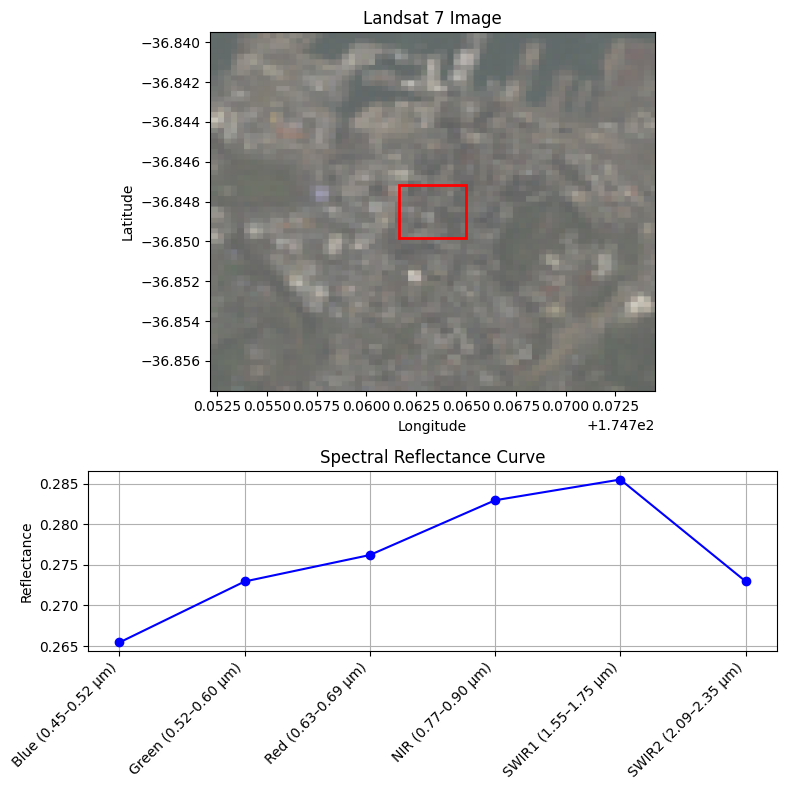

In [25]:
# Additional required packages
import matplotlib.patches as patches # allows you to draw geometric shapes  onto plots
import urllib.request # allows python to get data files etc from webpages and URLs
import tempfile # creates tempry files that delate when you exit the script
import matplotlib.image as mpimg # provides functions to read load and reander image files

# Define point and regions
# defines the AOI
point = ee.Geometry.Point([174.7633, -36.8485]) # defines region around auckland
region = point.buffer(150).bounds()        # ~300 m box
expanded_region = point.buffer(1000).bounds()  # box for image preview

# Load Landsat 7 surface reflectance image
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()
    #Takes the first image

# Define bands and scaling
# selects 6 specterual bands and converts the raw pixel values to surface reflectance
# this is doneusing the landsat scaling facotr 2.75e-5

bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}
scale_factor = 2.75e-5 # becuse they are stored in digital numbers so converts them into true optical reflectance values.


# Calculate mean reflectance
# averages the pixel values across the 300m AOI using the mean reducer
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6).getInfo()

reflectance = [mean_dict[b] * scale_factor for b in bands] # takes the raw average values for each spectrual band and multiplys them by the scale factor
labels = list(band_names.values()) # extracts the the descriptive naes from band_names and converts them into the list of text strings

# Get RGB thumbnail slightly zoomed out
# makes a true colour composite using red, green, and blue colour bands over the area and making a temorpy web url for downlowd
thumb_params = {
    'dimensions': 512,
    'region': expanded_region,
    'format': 'png',
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0, # adust the raw brightness levels
    'max': 30000,
    'gamma': 1.4 # inhances visual contrast
}
url = image.getThumbURL(thumb_params)

# Get coordinates of regions
# extracts the longatude and latatude boundries from earth engine geometry objects
# becuse Matplotlib renders images in pixal coordnates so using the geographic coordnated allows the satlite image to alinge with the long lat axis
def get_bounds_coords(bounds): # defines a new function with the input agument bounds
    coords = bounds.coordinates().getInfo()[0] # extracts the coner points of the boundy box [0]asses the first element in the list
    lons = [pt[0] for pt in coords] # creats a lit with only the longatude values
    lats = [pt[1] for pt in coords] # creates a list with only the latatude values
    return min(lons), max(lons), min(lats), max(lats) #calculates and returnes the values representing the geographic boundires e.g min(lons)= western boundry xmin

# Extract bounding boxes
xmin, xmax, ymin, ymax = get_bounds_coords(expanded_region) # executes the above function on the expanded region and unpacks the 4 returned values into 4 variables
rxmin, rxmax, rymin, rymax = get_bounds_coords(region) # Excutes the above function but with the smaller area.

# Plot both panels
# sets up a two row layout where the top panel is twice as tall as the bottom panel
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [2, 1]})

# Load and plot image with annotation
# downloads the image theubnail into a tempry file, displays it as a spacial map in ax1
with tempfile.NamedTemporaryFile(suffix=".png") as f:
    urllib.request.urlretrieve(url, f.name)
    img = mpimg.imread(f.name)
    ax1.imshow(img, extent=[xmin, xmax, ymin, ymax])
    ax1.set_title("Landsat 7 Image")
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)

    # Add red rectangle for region of interest
    # and then daws a red box overlay highliting the 300m target area

    width = rxmax - rxmin
    height = rymax - rymin
    rect = patches.Rectangle((rxmin, rymin), width, height,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")

# Plot reflectance
#plots the multi-spectural reflectance curve on ax2 with point markers connected across wavelengths.
ax2.plot(labels, reflectance, marker='o', color='blue')
ax2.set_title("Spectral Reflectance Curve")
ax2.set_ylabel("Reflectance")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(True)

plt.tight_layout()
plt.show()


(8) Exercise: Using Sentinel 2, create a figure that does the following over the city of Christchurch, NZ:
*   Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.
* Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.
* Gives examples of the sample areas that you have used to create these spectral signatures.

Provide a publication quality copy of this figure in the answer proforma. Publication quality means that:  
1.   It is at a good quality (resolution) and not blurry.
2.   The font size of all elements is big enough to read easily on a screen when placed in the document.
3. Has a figure caption that ensures the reader knows what you have done and why.
4. Tells the story 'at a glance'. Don't make your viewer work too hard to understand your core message.

See the Nature guide linked at the start of this lab for more detail on what I expect.

(25 pts)




In [38]:
# Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.


# Define small region around Christchurch, NZ
point = ee.Geometry.Point([172.636, -43.532])
region = point.buffer(150).bounds()
expanded_region = point.buffer(1000).bounds()

# Load the image with least cloud cover in 2002
image = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(region) \
    .filterDate("2002-01-01", "2002-12-31") \
    .sort("CLOUD_COVER") \
    .first()


# Check metadata
print('Image ID:', image.get('LANDSAT_PRODUCT_ID').getInfo())
print('Cloud Cover (whole scene):', image.get('CLOUD_COVER').getInfo())

# Function to mask clouds using QA_PIXEL band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 and 4 are cloud and cloud shadow respectively
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(
                 qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(cloud_mask)

# Apply mask
masked_image = mask_clouds(image)

# Report Image Quality Over ROI
# Total pixels in region
pixel_area = ee.Image.pixelArea().clip(region)

# Count valid pixels before and after masking
total_pixels = pixel_area.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['area']

valid_pixels = masked_image.select('SR_B3').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['SR_B3']

cloud_coverage_pct = 100 * (1 - valid_pixels / total_pixels)

print(f"Total Pixels: {total_pixels}")
print(f"Valid (non-cloud) Pixels: {valid_pixels}")
print(f"Estimated Cloud Coverage in ROI: {cloud_coverage_pct:.2f}%")

Map = geemap.Map(center=[-43.532, 172.636], zoom=12)

vis = {
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}
Map.addLayer(image, vis, 'Original Image (Cloudy)')
Map.addLayer(masked_image, vis, 'Cloud Masked')
Map



Image ID: LE07_L2SP_073090_20021014_20200916_02_T1
Cloud Cover (whole scene): 1
Total Pixels: 140
Valid (non-cloud) Pixels: 98
Estimated Cloud Coverage in ROI: 30.00%


Map(center=[-43.532, 172.636], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

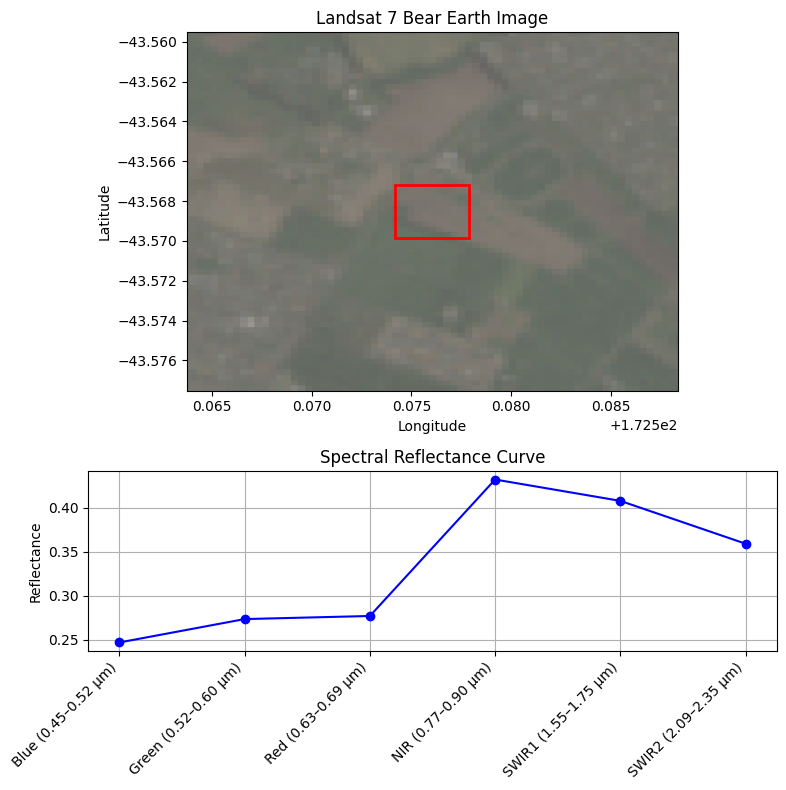

In [42]:
# Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.
# ok so you have to find an areas within christchurch that are examples of water, urban, forst, grassland and bare earth and map
# need to do a spectrual reflectance curve for each of them, but they all have to go onto the same plot.
# then have to show what areas i choose to map for the diffrent landuse types - do this the same as the red box image above but one for each.

# Additional required packages - is this nesscerary a second time?
import matplotlib.patches as patches # allows you to draw geometric shapes  onto plots
import urllib.request # allows python to get data files etc from webpages and URLs
import tempfile # creates tempry files that delate when you exit the script
import matplotlib.image as mpimg # provides functions to read load and reander image files

# bear earth.

# Define point and regions
# defines the AOI
point = ee.Geometry.Point([172.576039, -43.568528]) # defines region around bear earth
region = point.buffer(150).bounds()        # ~300 m box
expanded_region = point.buffer(1000).bounds()  # box for image preview

# forested
point2 = ee.Geometry.Point([172.633661, -43.595431]) # defines region around bear earth
region = point.buffer(150).bounds()        # ~300 m box
expanded_region = point.buffer(1000).bounds()

# Load Landsat 7 surface reflectance image
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()
    #Takes the first image

# Define bands and scaling
# selects 6 specterual bands and converts the raw pixel values to surface reflectance
# this is doneusing the landsat scaling facotr 2.75e-5

bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}
scale_factor = 2.75e-5 # becuse they are stored in digital numbers so converts them into true optical reflectance values.


# Calculate mean reflectance
# averages the pixel values across the 300m AOI using the mean reducer
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6).getInfo()

reflectance = [mean_dict[b] * scale_factor for b in bands] # takes the raw average values for each spectrual band and multiplys them by the scale factor
labels = list(band_names.values()) # extracts the the descriptive naes from band_names and converts them into the list of text strings

# Get RGB thumbnail slightly zoomed out
# makes a true colour composite using red, green, and blue colour bands over the area and making a temorpy web url for downlowd
thumb_params = {
    'dimensions': 512,
    'region': expanded_region,
    'format': 'png',
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0, # adust the raw brightness levels
    'max': 30000,
    'gamma': 1.4 # inhances visual contrast
}
url = image.getThumbURL(thumb_params)

# Get coordinates of regions
# extracts the longatude and latatude boundries from earth engine geometry objects
# becuse Matplotlib renders images in pixal coordnates so using the geographic coordnated allows the satlite image to alinge with the long lat axis
def get_bounds_coords(bounds): # defines a new function with the input agument bounds
    coords = bounds.coordinates().getInfo()[0] # extracts the coner points of the boundy box [0]asses the first element in the list
    lons = [pt[0] for pt in coords] # creats a lit with only the longatude values
    lats = [pt[1] for pt in coords] # creates a list with only the latatude values
    return min(lons), max(lons), min(lats), max(lats) #calculates and returnes the values representing the geographic boundires e.g min(lons)= western boundry xmin

# Extract bounding boxes
xmin, xmax, ymin, ymax = get_bounds_coords(expanded_region) # executes the above function on the expanded region and unpacks the 4 returned values into 4 variables
rxmin, rxmax, rymin, rymax = get_bounds_coords(region) # Excutes the above function but with the smaller area.

# Plot both panels
# sets up a two row layout where the top panel is twice as tall as the bottom panel
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [2, 1]})

# Load and plot image with annotation
# downloads the image theubnail into a tempry file, displays it as a spacial map in ax1
with tempfile.NamedTemporaryFile(suffix=".png") as f:
    urllib.request.urlretrieve(url, f.name)
    img = mpimg.imread(f.name)
    ax1.imshow(img, extent=[xmin, xmax, ymin, ymax])
    ax1.set_title("Landsat 7 Bear Earth Image")
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)

    # Add red rectangle for region of interest
    # and then daws a red box overlay highliting the 300m target area

    width = rxmax - rxmin
    height = rymax - rymin
    rect = patches.Rectangle((rxmin, rymin), width, height,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")

# Plot reflectance
#plots the multi-spectural reflectance curve on ax2 with point markers connected across wavelengths.
ax2.plot(labels, reflectance, marker='o', color='blue')
ax2.set_title("Spectral Reflectance Curve")
ax2.set_ylabel("Reflectance")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(True)

plt.tight_layout()
plt.show()

















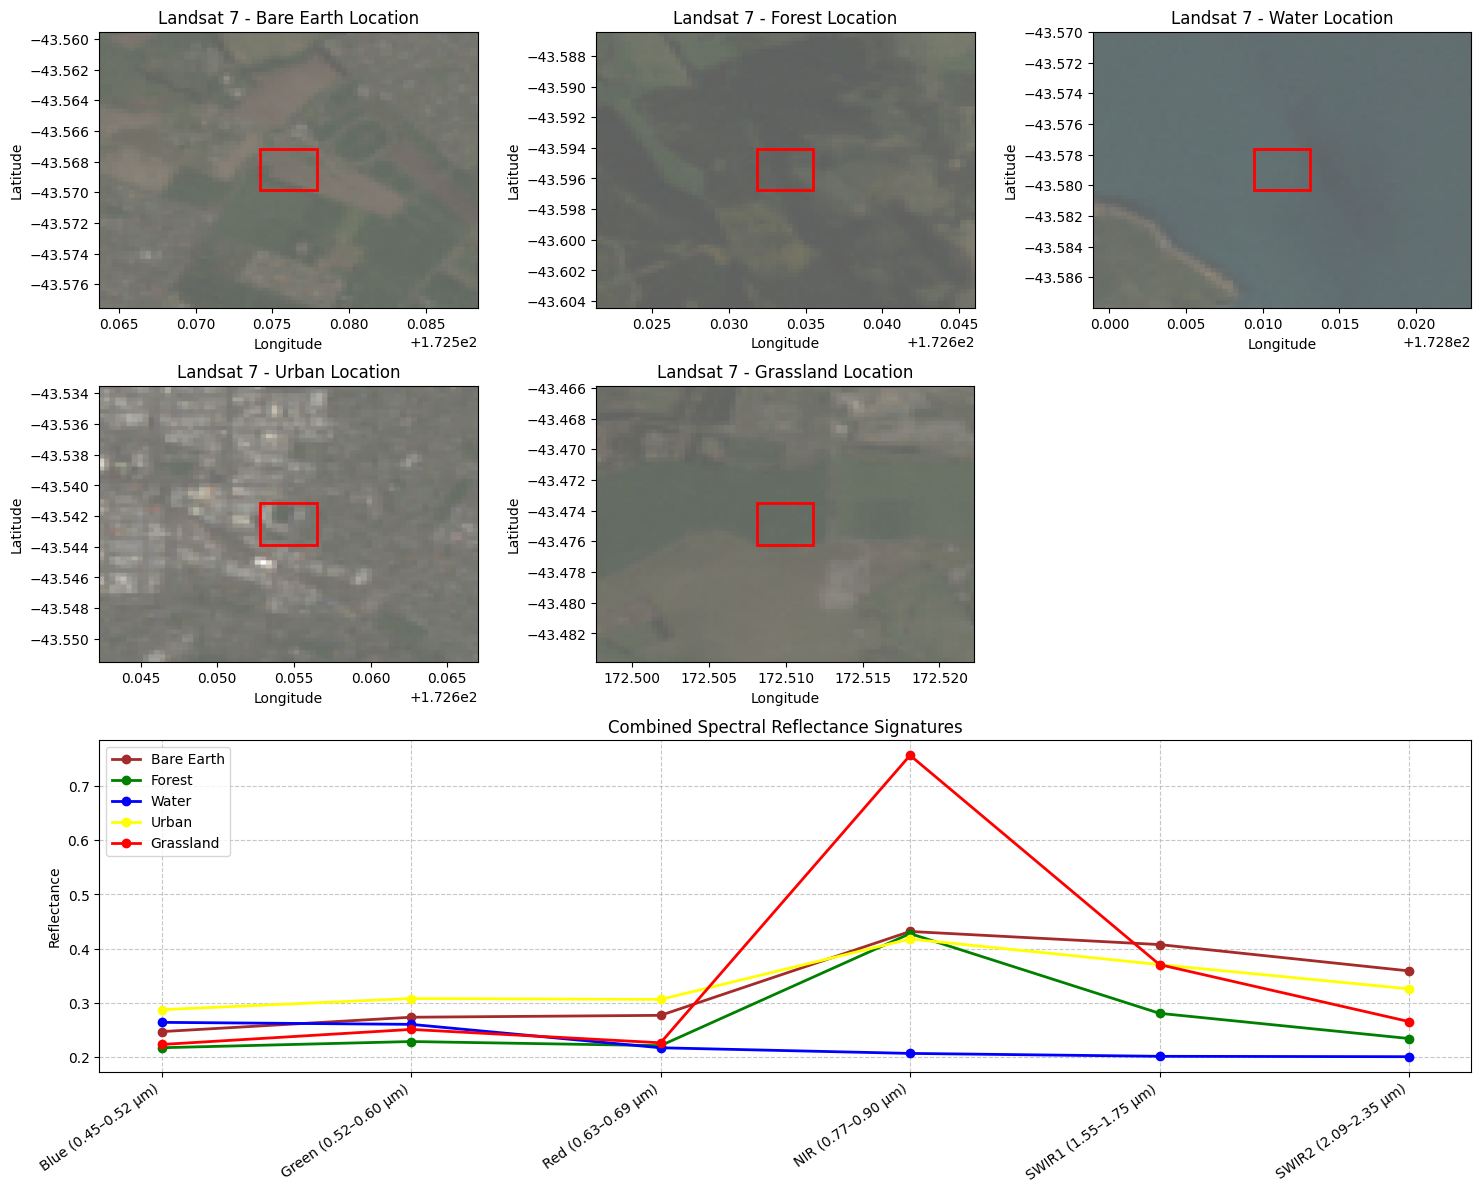

In [47]:
import tempfile
import urllib.request
import ee
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib.pyplot as plt
# -----------------------------------------------------------------
# 1. Define the points and regions for each landcover type

# Land Cover 1: Bare Earth
point_bare = ee.Geometry.Point([172.576039, -43.568528])
region_bare = point_bare.buffer(150).bounds()
expanded_bare = point_bare.buffer(1000).bounds()

# Land Cover 2: Forested
point_forest = ee.Geometry.Point([172.633661, -43.595431])
region_forest = point_forest.buffer(150).bounds()
expanded_forest = point_forest.buffer(1000).bounds()

# Land Cover 3: Water
point_Water = ee.Geometry.Point([172.811244, -43.578994])
region_Water = point_Water.buffer(150).bounds()
expanded_Water = point_Water.buffer(1000).bounds()

# Land Cover 4: Urban
Point_urban = ee.Geometry.Point([172.654625, -43.542519])
region_urban = Point_urban.buffer(150).bounds()
expanded_urban = Point_urban.buffer(1000).bounds()

# Land Cover 5: Grassland
Point_grassland = ee.Geometry.Point([172.509942, -43.474875])
region_grassland = Point_grassland.buffer(150).bounds()
expanded_grassland = Point_grassland.buffer(1000).bounds()

# Combine land covers into a dictionary for clean looping
locations = {
    "Bare Earth": {
        "region": region_bare,
        "expanded": expanded_bare,
        "color": "brown",
    },
    "Forest": {
        "region": region_forest,
        "expanded": expanded_forest,
        "color": "green",
    },
    "Water": {
        "region": region_Water,
        "expanded": expanded_Water,
        "color": "blue",
    },
    "Urban": {
        "region": region_urban,
        "expanded": expanded_urban,
        "color": "yellow",
    },
    "Grassland": {
        "region": region_grassland,
        "expanded": expanded_grassland,
        "color": "red",
    },
}

# -------------------------------------------------------------------
# 2. load landsat 7 image and define the bands

# Using combined geometry to find a single scene covering all points
combined_geometry = ee.Geometry.MultiPoint(
    [[172.576039, -43.568528], [172.633661, -43.595431], [172.811244, -43.578994],
     [172.654625, -43.542519], [172.509942, -43.474875]]
)

image = (
    ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
    .filterBounds(combined_geometry)
    .filterDate("2002-01-01", "2002-12-31")
    .sort("CLOUD_COVER")
    .first()
)

bands = ["SR_B1", "SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B7"]
band_names = {
    "SR_B1": "Blue (0.45–0.52 μm)",
    "SR_B2": "Green (0.52–0.60 μm)",
    "SR_B3": "Red (0.63–0.69 μm)",
    "SR_B4": "NIR (0.77–0.90 μm)",
    "SR_B5": "SWIR1 (1.55–1.75 μm)",
    "SR_B7": "SWIR2 (2.09–2.35 μm)",
}
labels = list(band_names.values())
scale_factor = 2.75e-5


# Helper function to get bounds in longitude/latitude
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)


# -------------------------------------------------------------------
# 3. calcualte the spectral refectance for all the locations

reflectance_data = {}

for name, info in locations.items():
    mean_dict = (
        image.select(bands)
        .reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=info["region"],
            scale=30,
            maxPixels=1e6,
        )
        .getInfo()
    )

    reflectance_data[name] = [mean_dict[b] * scale_factor for b in bands]

# -------------------------------------------------------------------
# 4. plot the maps and spectrual reflectance curve


# Create layout: Row 1 = Location maps side-by-side, Row 2 = Combined Spectral Curve
fig = plt.figure(figsize=(15, 12))
grid = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1.2])

# Create axes: top-left for Bare Earth map, top-right for Forest map, bottom spans both for plot
ax_map_bare = fig.add_subplot(grid[0, 0])
ax_map_forest = fig.add_subplot(grid[0, 1])
ax_map_water = fig.add_subplot(grid[0, 2])
ax_map_urban = fig.add_subplot(grid[1, 0])
ax_map_grassland = fig.add_subplot(grid[1, 1])
ax_unused = fig.add_subplot(grid[1, 2])
ax_unused.axis("off")
ax_plot = fig.add_subplot(grid[2, :])

map_axes = {"Bare Earth": ax_map_bare, "Forest": ax_map_forest,
            "Water": ax_map_water, "Urban": ax_map_urban, "Grassland": ax_map_grassland}

# Plot thumbnails with red bounding boxes
thumb_params = {
    "dimensions": 512,
    "format": "png",
    "bands": ["SR_B3", "SR_B2", "SR_B1"],
    "min": 0,
    "max": 30000,
    "gamma": 1.4,
}

for name, info in locations.items():
    ax = map_axes[name]

    # Get thumbnail URL for this location's expanded region
    params = thumb_params.copy()
    params["region"] = info["expanded"]
    url = image.getThumbURL(params)

    # Get coordinates
    xmin, xmax, ymin, ymax = get_bounds_coords(info["expanded"])
    rxmin, rxmax, rymin, rymax = get_bounds_coords(info["region"])

    # Load and display image
    with tempfile.NamedTemporaryFile(suffix=".png") as f:
        urllib.request.urlretrieve(url, f.name)
        img = mpimg.imread(f.name)
        ax.imshow(img, extent=[xmin, xmax, ymin, ymax])

    # Add red rectangle
    width = rxmax - rxmin
    height = rymax - rymin
    rect = patches.Rectangle(
        (rxmin, rymin),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax.add_patch(rect)

    ax.set_title(f"Landsat 7 - {name} Location")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

# Plot combined spectral curves on the bottom axes
for name, refl in reflectance_data.items():
    color = locations[name]["color"]
    ax_plot.plot(labels, refl, marker="o", color=color, label=name, linewidth=2)

ax_plot.set_title("Combined Spectral Reflectance Signatures")
ax_plot.set_ylabel("Reflectance")
ax_plot.set_xticks(range(len(labels)))
ax_plot.set_xticklabels(labels, rotation=35, ha="right")
ax_plot.grid(True, linestyle="--", alpha=0.7)
ax_plot.legend(loc="upper left")

plt.tight_layout()
plt.show()